In [6]:
import lfox
import lfox.lattice as lat
import jax
import jax.numpy as jnp
import numpy as np

from lfox.evolution import HMC, Chain, LeapfrogIntegrator, OmelyanIntegrator

# Imports below require "dev" environment
import matplotlib.pyplot as plt
import lsqfit
import gvar as gv
import tqdm

# Double precision!
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_threefry_partitionable", True)


In [7]:
class ScalarAction(lhmc.Action):        

    @staticmethod
    @jax.jit
    def _S(fields, params):
        phi = fields[0]
        S = phi**2
        
        for ax in range(phi.d()):
            S -= 2 * params['kappa'] * phi * phi.nn_field(ax)

        S += params['lambda'] * (phi**2 - 1)**2
        return S
    
    # Exact force function instead of autodiff, for testing purposes
    @staticmethod
    @jax.jit
    def exact_force(fields, params):
        phi = fields[0]

        J = phi.nn_field(axis=0, shift=1) + phi.nn_field(axis=0, shift=-1)
        for ax in range(1,phi.d):
            J += phi.nn_field(axis=ax, shift=1)
            J += phi.nn_field(axis=ax, shift=-1)

        F = -2 * params['kappa'] * J
        F += 2 * phi.F
        F += 4 * params['lambda'] * (phi.F**2 - 1) * phi.F

        return F

In [17]:
%%time

# First test case: exercise 2.5
d = 3
Lat4 = lat.SquareLattice(st_dims=((4,)*d))
phi4 = lat.LatticeField(lattice=Lat4, F=1)

S4 = ScalarAction(field_names=['phi'], params={'kappa': 0.18169, 'lambda': 1.3282})

all_Nstep = np.array([10, 20, 30, 40, 50])
all_eps = 1/all_Nstep

all_dH_leap = []
all_dH_om = []

for eps, Nstep in zip(all_eps, all_Nstep):
    hmc_leap = HMC(
        action = S4,
        integrator = LeapfrogIntegrator(eps=eps, Nstep=Nstep),
    )
    hmc_om = HMC(
        action = S4,
        integrator = OmelyanIntegrator(eps=eps, Nstep=Nstep),
    )

    F4 = {'phi': phi4}
    _, monitor_leap, _ = hmc_leap.evolve_many(
        F4, 
        jax.random.PRNGKey(72345), 
        traj=50
    )

    _, monitor_om, _ = hmc_om.evolve_many(
        F4, 
        jax.random.PRNGKey(87735),
        traj=50
    )

    abs_dH_leap = np.abs(np.array(monitor_leap['delta_H']))
    abs_dH_om = np.abs(np.array(monitor_om['delta_H']))

    all_dH_leap.append(gv.dataset.avg_data(abs_dH_leap))
    all_dH_om.append(gv.dataset.avg_data(abs_dH_om))


CPU times: user 29.9 ms, sys: 4.65 ms, total: 34.5 ms
Wall time: 26.8 ms


Least Squares Fit:
  chi2/dof [dof] = 0.67 [5]    Q = 0.65    logGBF = 5.0225

Parameters:
              a   -0.00090 (98)      [ 0 ± 1.0e+02 ]  
              b      18.0 (1.4)      [ 0 ± 5.0e+02 ]  

Settings:
  svdcut/n = 1e-12/0    tol = (1e-08*,1e-10,1e-10)    (itns/time = 5/0.0s)

Least Squares Fit:
  chi2/dof [dof] = 0.34 [5]    Q = 0.89    logGBF = 12.895

Parameters:
              a   0.6(9.4)e-05      [ 0 ± 1.0e+02 ]  
              b      1.64 (13)      [ 0 ± 5.0e+02 ]  

Settings:
  svdcut/n = 1e-12/0    tol = (1e-08*,1e-10,1e-10)    (itns/time = 6/0.0s)



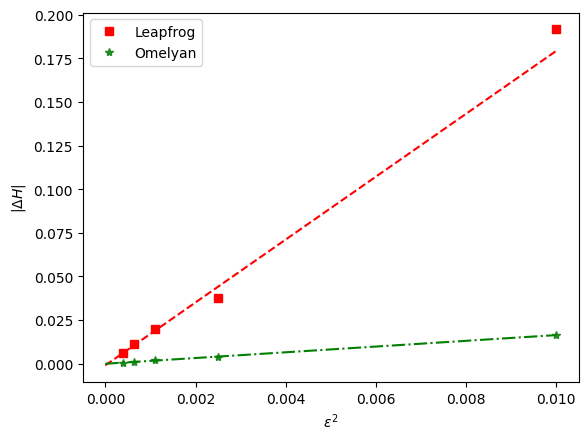

In [18]:
#Figure 2.2
plt.plot(all_eps**2, gv.mean(all_dH_leap), ls=' ', marker='s', color='red', label='Leapfrog')
plt.plot(all_eps**2, gv.mean(all_dH_om), ls=' ', marker='*', color='forestgreen', label='Omelyan')

def lin(x,p):
    return p['a'] + p['b']*x

fit_leap = lsqfit.nonlinear_fit(data=(all_eps**2, all_dH_leap), prior={'a': gv.gvar(0,100), 'b': gv.gvar(0,500)}, fcn=lin)
print(fit_leap)

eps_ls = np.linspace(0,0.1,100)
plt.plot(eps_ls**2, gv.mean(lin(eps_ls**2,fit_leap.p)), ls='--', color='red')

fit_om = lsqfit.nonlinear_fit(data=(all_eps**2, all_dH_om), prior={'a': gv.gvar(0,100), 'b': gv.gvar(0,500)}, fcn=lin)
print(fit_om)

plt.plot(eps_ls**2, gv.mean(lin(eps_ls**2,fit_om.p)), ls='-.', color='green')

plt.xlabel(r'$\epsilon^2$')
plt.ylabel(r'$|\Delta H|$')
plt.legend()

Another technical plot first: let's do figure 2.4.

In [26]:
%%time

# First test case: exercise 2.5
d = 3
Lat6 = lat.SquareLattice(st_dims=((6,)*d))
phi6 = lat.LatticeField(lattice=Lat6, F=1)

S6 = ScalarAction(field_names=['phi'], params={'kappa': 0.185825, 'lambda': 1.1689})

all_Nstep = np.array([4, 5, 7, 8, 10, 20, 30, 40, 50])
all_eps = 1/all_Nstep

all_acc_rate = []
rng_key = jax.random.PRNGKey(11134)

for eps, Nstep in zip(all_eps, all_Nstep):
    F6 = {'phi': phi6}
    hmc = lhmc.HMC(
        action=S6,
        integrator=LeapfrogIntegrator(eps=eps, Nstep=Nstep),
    )

    acc_rate = []
    for _ in range(1000):
        F6, mon, rng_key = hmc.evolve(F6, rng_key)
        acc_rate.append(mon['accept'])

    all_acc_rate.append(np.mean(np.array(acc_rate)))
    

CPU times: user 2.02 s, sys: 316 ms, total: 2.33 s
Wall time: 922 ms


Text(0, 0.5, 'acc rate')

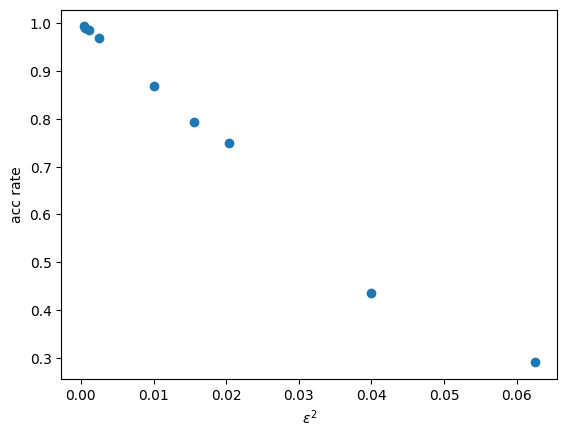

In [27]:
plt.plot(all_eps**2, all_acc_rate, ls=' ', marker='o')

plt.xlabel(r'$\epsilon^2$')
plt.ylabel(r'acc rate')

Text(0, 0.5, '$1/\\epsilon/$ acc rate [cost]')

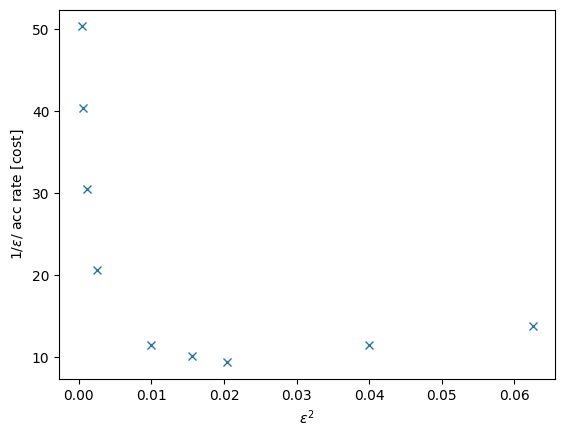

In [29]:
plt.plot(all_eps**2, 1/all_eps/all_acc_rate, ls=' ', marker='x')
plt.xlabel('$\\epsilon^2$')
plt.ylabel('$1/\\epsilon/$ acc rate [cost]')

Some additional technical tests.  Let's verify that $e^{-\Delta H}$ averages to 1 properly.

In [30]:
%%time
hmc = HMC(
    action=ScalarAction(field_names=['phi'], params={'kappa': 0.18, 'lambda': 1.145}),
    integrator=LeapfrogIntegrator(eps=0.1, Nstep=10),
)

Ftest = {'phi': phi6}
rng_key = jax.random.PRNGKey(21245)
dH_array = []
for _ in range(10000):
    Ftest, mon, rng_key = hmc.evolve(Ftest, rng_key)
    dH_array.append(mon['delta_H'])

CPU times: user 2.08 s, sys: 395 ms, total: 2.47 s
Wall time: 931 ms


1.015(24)

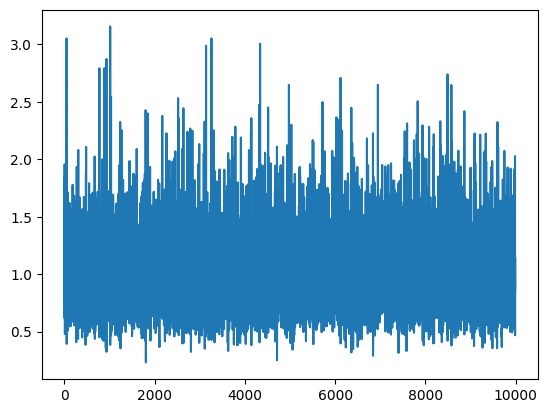

In [31]:
edH = np.exp(-np.array(dH_array))
plt.plot(edH[10:])
gv.dataset.avg_data(edH[100::50])  # Block by 50, should be consistent with 1

Now on to figure 2.3 and comparing HMC to MD.

In [32]:
@jax.jit
def mag(phi):
    m = jnp.sum(phi.F)
    return jnp.array([m, m**2, m**4])

def mag_obs(fields, params):
    return mag(fields['phi'])

In [34]:
%%prun -s cumulative

# Second test case: figure 2.3
d = 3
Lat6 = lat.SquareLattice(st_dims=((6,)*d))
phi6 = lat.LatticeField(lattice=Lat6, F=1)

all_Nstep = np.array([4,5,6,7,8,10])

# Try tau = 2
all_eps = 1/all_Nstep
m2_HMC = []
m2_HMD = []

raw_HMC = []
mon_HMC = []

rng_key = jax.random.PRNGKey(73645)
F6_HMC = {'phi': phi6}
F6_HMD = {'phi': phi6}

for eps, Nstep in zip(all_eps, all_Nstep):
    print(eps, Nstep)

    raw_m2_HMC = []
    raw_m2_HMD = []
    
    hmc = HMC(
        action=ScalarAction(field_names=['phi'], params={'kappa': 0.185825, 'lambda': 1.1689}),
        integrator=LeapfrogIntegrator(eps=eps, Nstep=Nstep),
    )
    
    for t in range(1000):

        F6_HMC, _, rng_key = hmc.evolve_many(F6_HMC, rng_key, traj=100)
        F6_HMD, _, rng_key = hmc.as_warmup().evolve_many(F6_HMD, rng_key, traj=100)

        raw_m2_HMC.append(mag(F6_HMC['phi'])[1]/6**d)
        raw_m2_HMD.append(mag(F6_HMD['phi'])[1]/6**d)
    
    m2_HMC.append(gv.dataset.avg_data(raw_m2_HMC))
    m2_HMD.append(gv.dataset.avg_data(raw_m2_HMD))



0.25 4
0.2 5
0.16666666666666666 6
0.14285714285714285 7
0.125 8
0.1 10
 

         9308309 function calls (8989460 primitive calls) in 34.009 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       28    0.000    0.000   34.127    1.219 base_events.py:1977(_run_once)
       27    0.086    0.003   31.338    1.161 selectors.py:540(select)
       33   10.173    0.308   24.361    0.738 {built-in method time.sleep}
    12000    0.030    0.000   16.260    0.001 array.py:338(__getitem__)
    12000    0.032    0.000   16.215    0.001 indexing.py:1061(rewriting_take)
    12000    0.030    0.000   15.845    0.001 indexing.py:1135(_static_slice)
24134/24132    0.075    0.000   15.719    0.001 core.py:646(bind)
    12006    0.012    0.000   15.460    0.001 slicing.py:62(slice)
24134/24132    0.025    0.000   15.457    0.001 core.py:664(bind_with_trace)
    24005    0.030    0.000   15.419    0.001 core.py:1211(process_primitive)
    24003   15.234    0.001   15.281    0.001 dispatch.py:83(apply_primitive)
 

<>:5: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:5: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/var/folders/vb/_ph7q5kx1db93rd8bw2112ph0000gn/T/ipykernel_91551/1386904723.py:5: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.xlabel('$\epsilon^2$')


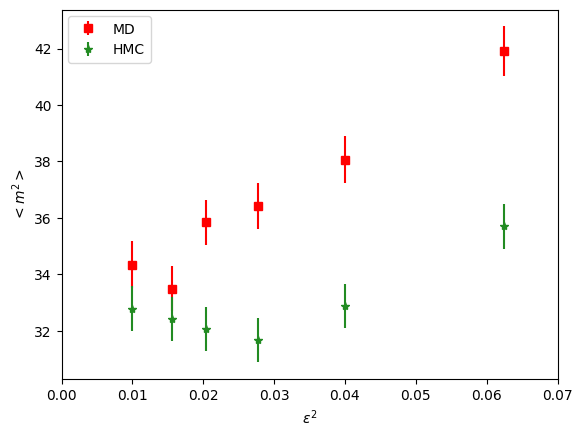

In [35]:
plt.errorbar(all_eps**2, gv.mean(m2_HMD), gv.sdev(m2_HMD), ls=' ', marker='s', color='red', label='MD')
plt.errorbar(all_eps**2, gv.mean(m2_HMC), gv.sdev(m2_HMC), ls=' ', marker='*', color='forestgreen', label='HMC')

plt.xlim(0,0.07)
plt.xlabel('$\epsilon^2$')
plt.ylabel('$<m^2>$')
plt.legend()

Finally the big physics result, figure 2.5!

In [37]:
from tqdm import tqdm

d = 3

all_kappa = np.array([0.05, 0.10, 0.15, 0.16, 0.17, 0.175, 0.18, 0.185, 0.19, 0.195, 0.2, 0.21, 0.22])
all_L = (6,8,10)

mag_k = {}
rng_key = jax.random.PRNGKey(58105)

for L in tqdm(all_L):
    mag_k[L] = []

    Lat = lat.SquareLattice(st_dims=((L,)*d))
    phi_L = lat.LatticeField(lattice=Lat, F=1)

    for k in all_kappa:
        raw_mag = []
        fields = {'phi': phi_L}
        Sk = ScalarAction(field_names=['phi'], params={'kappa': k, 'lambda': 1.1689})
    
        hmc = HMC(
            action=Sk,
            integrator=OmelyanIntegrator(eps=0.1, Nstep=10),
        )

        fields, _, rng_key = hmc.as_warmup().evolve_many(fields, rng_key, traj=100)
    
        for _ in range(200):
            fields, _, rng_key = hmc.evolve_many(fields, rng_key, traj=100)
            raw_mag.append(mag(fields['phi'])[0])
    
        raw_m = np.abs(np.array(raw_mag))/L**d
    
        mag_k[L].append(gv.dataset.avg_data(raw_m))
    

  0%|                                                                                                                                                                                                                                                  | 0/3 [00:00<?, ?it/s]/var/folders/vb/_ph7q5kx1db93rd8bw2112ph0000gn/T/ipykernel_91551/3292238743.py:20: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  Sk = ScalarAction(field_names=['phi'], params={'kappa': k, 'lambda': 1.1689})
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [01:42<00:00, 34.18s/it]


(0.15, 0.22)

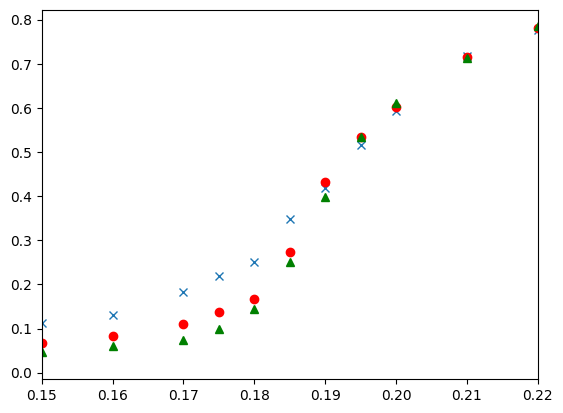

In [38]:
plt.plot(all_kappa, gv.mean(mag_k[6]), ls=' ', marker='x')
plt.plot(all_kappa, gv.mean(mag_k[8]), ls=' ', marker='o', color='red')
plt.plot(all_kappa, gv.mean(mag_k[10]), ls=' ', marker='^', color='green')

plt.xlim(0.15, 0.22)

Autocorrelation analysis...

In [40]:
## Rewrite this using Chain?  (and maybe some of the above too?)

d = 3
Lat6 = lat.SquareLattice(st_dims=((6,)*d))
phi6 = lat.LatticeField(Lat6)
rng_key = jax.random.PRNGKey(21245)

hmc = HMC(
    action=ScalarAction(field_names=['phi'], params={'kappa': 0.185825, 'lambda': 1.1689}),
    seed=21245,
    init_fields={'phi': phi6},
    integrator=OmelyanIntegrator(eps=0.1, Nstep=10),
    observables={'mag': (mag_obs, 1)},
)

hmc.as_warmup().evolve(ntraj=1000, warmup=True)

for _ in tqdm(range(1000)):
    hmc.evolve(ntraj=1000)

TypeError: LatticeField.__init__() missing 1 required positional argument: 'F'

In [22]:
dH = np.array(HMC.monitor['delta_H'])
gv.dataset.avg_data(np.exp(-dH))

1.000003(36)

0.0096(39)

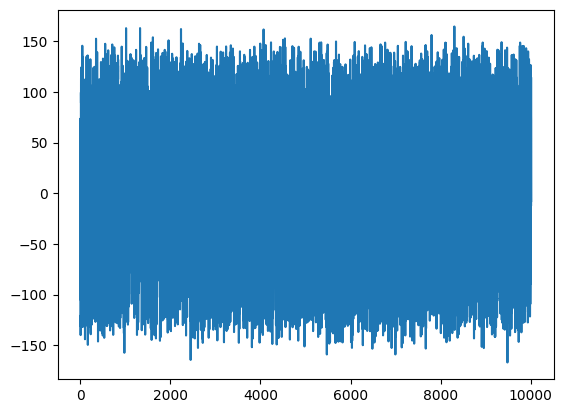

In [23]:
m = np.array(HMC.obs_chain['mag'])[:,0]
plt.plot(m[::100])

gv.dataset.avg_data(m[::100]/6**3)

In [24]:
mu, Ns = np.mean(m), len(m)
print(mu, Ns)

def Gamma(t):
    C1 = m - mu
    C2 = np.roll(m, t) - mu
    return gv.dataset.avg_data(C1[:Ns-t] * C2[:Ns-t] / (Ns - t))

2.301753935610712 1001000


<ErrorbarContainer object of 3 artists>

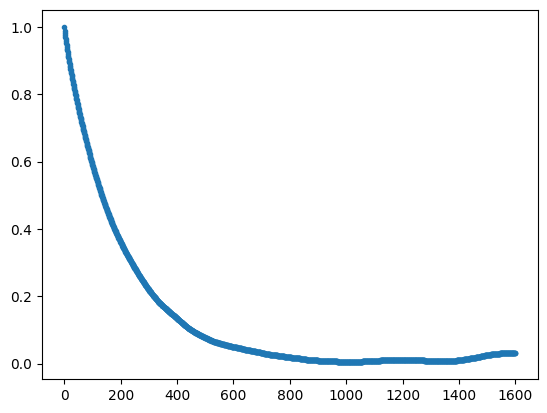

In [25]:
gam = [ Gamma(t)/Gamma(0) for t in range(0,1600) ]
plt.errorbar(range(0,1600), gv.mean(gam), gv.sdev(gam), ls=' ', marker='.')

<ErrorbarContainer object of 3 artists>

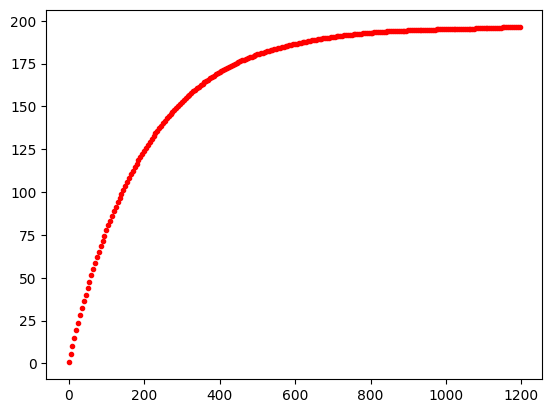

In [26]:
def tau(W):
    return 0.5 + np.sum(gam[:W])

taus = [ tau(W) for W in range(0,1200,5) ]
plt.errorbar(range(0,1200,5), gv.mean(taus), gv.sdev(taus), ls=' ', marker='.', color='red')